In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
import math
from pathlib import Path
import matplotlib.pyplot as plt

### Loading data

In [2]:
mg_intg = ad.read_h5ad(
    "/data/scRNA/Hammond/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA.h5ad"
    )
hMEs_df = pd.read_csv(
    "/data/scRNA/Hammond/Modules/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA_harmonized_MEs.csv",
    index_col=0
    )
MEs_df = pd.read_csv(
    "/data/scRNA/Hammond/Modules/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA_MEs.csv",
    index_col=0
    )

In [26]:
# # Loading the combined modules dataframe
# modules_df = pd.read_csv("/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_combined_modules.csv", index_col=0)
# modules_df.head()

In [3]:
# Renaming the modules in the modules dataframe
Hammond_rename_map = {
    "MG-Control-M1": "Motility & Phagocytosis",
    # "MG-Control-M2": "Interferon Response",
    # "MG-Control-M3": "Antigen Presentation & Apoptosis",
    "MG-Control-M4": "Homeostasis",
    # "MG-Saline-M1": "Interferon Response",
    "MG-Saline-M2": "Metabolic Regulation",
    # "MG-Saline-M3": "Antigen Presentation & Apoptosis",
    "MG-LC-M1": "Interferon Response",
    "MG-LC-M2": "Antigen Presentation & Apoptosis",
    "MG-LC-M3": "Gliosis"
}

In [27]:
# # Make a copy of the original dataframe
# modules_rn_df = modules_df.copy()

# # Get the keys of the dictionary
# columns_to_keep = Hammond_rename_map.keys()

# # Keep only the columns that exist in the dictionary keys
# modules_rn_df = modules_rn_df.loc[:, modules_rn_df.columns.intersection(columns_to_keep)]
# modules_rn_df.head()

In [4]:
# modules_rn_df.rename(columns=Hammond_rename_map, inplace=True)
# modules_rn_df.head()

In [4]:
# Make a copy of the original dataframe
MEs_rn_df = MEs_df.copy()

# Get the keys of the dictionary
columns_to_keep = Hammond_rename_map.keys()

# Keep only the columns that exist in the dictionary keys
MEs_rn_df = MEs_rn_df.loc[:, MEs_rn_df.columns.intersection(columns_to_keep)]

# Rename the columns using the Hammond_rename_map
MEs_rn_df.rename(columns=Hammond_rename_map, inplace=True)
MEs_rn_df.head()

,Motility & Phagocytosis,Homeostasis,Metabolic Regulation,Interferon Response,Antigen Presentation & Apoptosis,Gliosis
TTAGGACAGAGGGCTT-1-0,0.255532,0.417849,-1.788942,-2.792273,-1.708830,-0.862438
GGCGACTTCCAAATGC-1-0,-0.485077,0.786505,-0.522096,-0.370044,-0.237307,0.177876
TCATTACTCGTGGACC-1-0,0.637588,3.614104,-0.337107,-1.715240,0.726709,-0.620130
GCAAACTTCGGCGGTT-1-0,12.113308,-0.661325,0.507050,15.611299,2.650271,1.048490
GGAATAATCACAGGCC-1-0,-0.724003,4.541356,-1.524848,-0.908908,0.616980,0.030042


### Overlap of modules

In [6]:
# from itertools import product

# # Calculate Jaccard Index overlap between all modules across all conditions

# # Collect all module names and their gene sets
# module_gene_sets = {}
# for cond, df in module_dfs.items():
#     for mod in df['module'].unique():
#         if mod == "grey":
#             continue
#         module_gene_sets[mod] = set(df[df['module'] == mod].index)

# # Prepare module list for consistent ordering
# all_modules = list(module_gene_sets.keys())

# # Compute Jaccard Index matrix
# jaccard_matrix = pd.DataFrame(
#     np.zeros((len(all_modules), len(all_modules))),
#     index=all_modules,
#     columns=all_modules
# )

# for m1, m2 in product(all_modules, repeat=2):
#     genes1 = module_gene_sets[m1]
#     genes2 = module_gene_sets[m2]
#     intersection = len(genes1 & genes2)
#     union = len(genes1 | genes2)
#     jaccard_matrix.loc[m1, m2] = intersection / union if union > 0 else 0

# # Plot heatmap
# plt.figure(figsize=(8, 8))
# sns.heatmap(jaccard_matrix, cmap='Blues', annot=True, fmt=".2f")
# plt.title('Jaccard Index Overlap of Module Genes')
# plt.xlabel('Modules')
# plt.ylabel('Modules')
# plt.tight_layout()
# plt.show()

In [7]:
# from itertools import product

# # Calculate Overlap Coefficient between all modules across all conditions

# # Collect all module names and their gene sets
# module_gene_sets = {}
# for cond, df in module_dfs.items():
#     for mod in df['module'].unique():
#         if mod == "grey":
#             continue
#         module_gene_sets[mod] = set(df[df['module'] == mod].index)

# # Prepare module list for consistent ordering
# all_modules = list(module_gene_sets.keys())

# # Compute Overlap Coefficient matrix
# overlap_matrix = pd.DataFrame(
#     np.zeros((len(all_modules), len(all_modules))),
#     index=all_modules,
#     columns=all_modules
# )

# for m1, m2 in product(all_modules, repeat=2):
#     genes1 = module_gene_sets[m1]
#     genes2 = module_gene_sets[m2]
#     intersection = len(genes1 & genes2)
#     min_size = min(len(genes1), len(genes2))
#     overlap_matrix.loc[m1, m2] = intersection / min_size if min_size > 0 else 0

# # Plot heatmap
# plt.figure(figsize=(8, 8))
# sns.heatmap(overlap_matrix, cmap='Blues', annot=True, fmt=".2f")
# plt.title('Overlap Coefficient of Module Genes')
# plt.xlabel("")
# plt.ylabel("")
# plt.tight_layout()
# # plt.savefig("figures/Heatmap_Overlap_Coefficient_Hammond_modules.svg")
# plt.show()

### Visualization: Box plot

In [5]:
# Create a copy of the metadata
meta_df = mg_intg.obs.copy()

In [6]:
# Ensure the indices match before joining
assert all(MEs_df.index == meta_df.index)

# Add the module eigengenes to mg_intg.obs
meta_df = meta_df.join(MEs_df)

# Optionally, verify the new columns are present
meta_df.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,Condition,leiden_res_0.3,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
TTAGGACAGAGGGCTT-1-0,0,1229,1229,1922.0,6.0,0.312175,Control,0,0.255532,-2.041716,-3.615439,0.417849,-2.562782,-1.788942,-1.610221,-2.792273,-1.708830,-0.862438
GGCGACTTCCAAATGC-1-0,0,2187,2187,4954.0,21.0,0.423900,Control,1,-0.485077,-0.585895,-0.099084,0.786505,-0.341131,-0.522096,-0.121973,-0.370044,-0.237307,0.177876
TCATTACTCGTGGACC-1-0,0,2086,2086,5015.0,29.0,0.578265,Control,0,0.637588,-1.652849,-0.038324,3.614104,-1.708821,-0.337107,0.554722,-1.715240,0.726709,-0.620130
GCAAACTTCGGCGGTT-1-0,0,1804,1804,4764.0,8.0,0.167926,Control,2,12.113308,14.555859,2.500947,-0.661325,15.040797,0.507050,2.742788,15.611299,2.650271,1.048490
GGAATAATCACAGGCC-1-0,0,2002,2002,4264.0,10.0,0.234522,Control,0,-0.724003,-0.886679,-0.425213,4.541356,-1.305562,-1.524848,0.625006,-0.908908,0.616980,0.030042


In [7]:
# Create a copy of the metadata
meta_rn_df = mg_intg.obs.copy()

# Ensure the indices match before joining
assert all(MEs_rn_df.index == meta_rn_df.index)

# Add the module eigengenes to mg_intg.obs
meta_rn_df = meta_rn_df.join(MEs_rn_df)

# Optionally, verify the new columns are present
meta_rn_df.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,Condition,leiden_res_0.3,Motility & Phagocytosis,Homeostasis,Metabolic Regulation,Interferon Response,Antigen Presentation & Apoptosis,Gliosis
TTAGGACAGAGGGCTT-1-0,0,1229,1229,1922.0,6.0,0.312175,Control,0,0.255532,0.417849,-1.788942,-2.792273,-1.708830,-0.862438
GGCGACTTCCAAATGC-1-0,0,2187,2187,4954.0,21.0,0.423900,Control,1,-0.485077,0.786505,-0.522096,-0.370044,-0.237307,0.177876
TCATTACTCGTGGACC-1-0,0,2086,2086,5015.0,29.0,0.578265,Control,0,0.637588,3.614104,-0.337107,-1.715240,0.726709,-0.620130
GCAAACTTCGGCGGTT-1-0,0,1804,1804,4764.0,8.0,0.167926,Control,2,12.113308,-0.661325,0.507050,15.611299,2.650271,1.048490
GGAATAATCACAGGCC-1-0,0,2002,2002,4264.0,10.0,0.234522,Control,0,-0.724003,4.541356,-1.524848,-0.908908,0.616980,0.030042


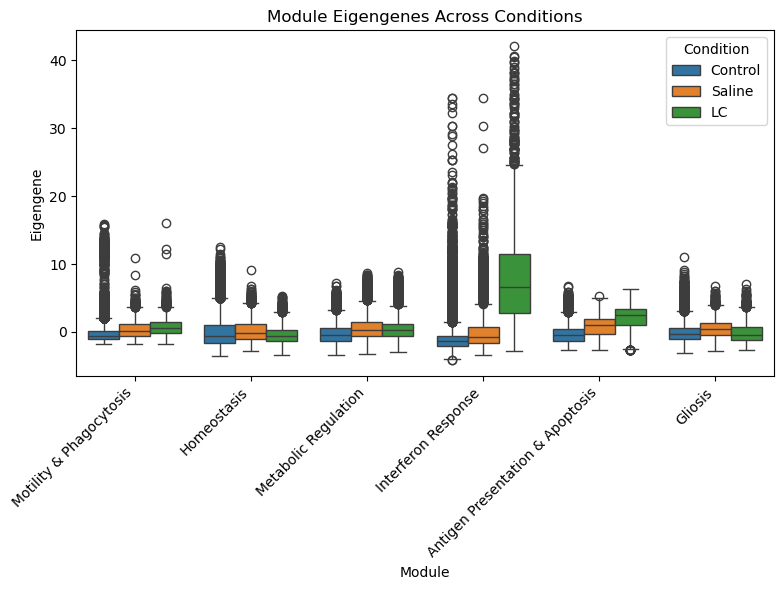

In [8]:
# Select module eigengene columns
me_cols = MEs_rn_df.columns.tolist()

# Melt the dataframe for seaborn boxplot
plot_df = meta_rn_df[me_cols + ['Condition']].melt(id_vars='Condition', var_name='Module', value_name='Eigengene')

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Module', y='Eigengene', hue='Condition')
plt.xticks(rotation=45, ha='right')
plt.title('Module Eigengenes Across Conditions')
plt.tight_layout()
# plt.savefig("figures/Boxplot_Module_Eigengenes_Hammond.svg")
plt.show()

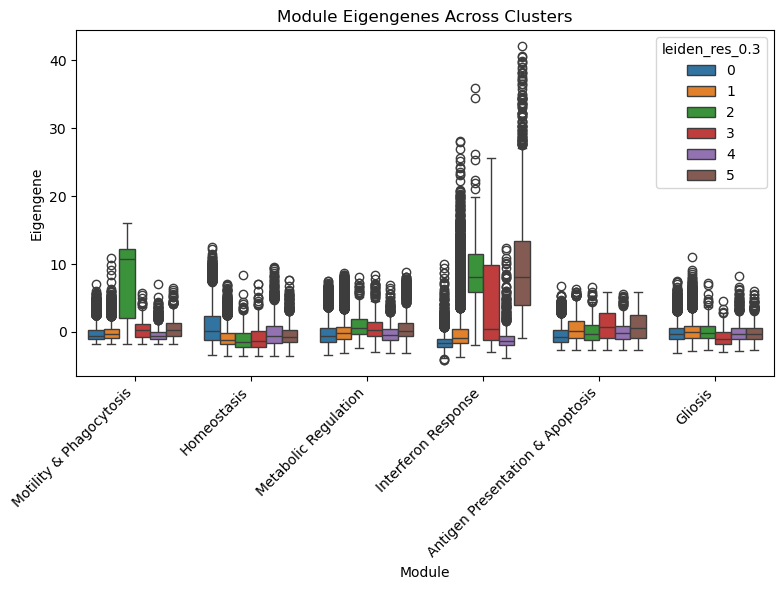

In [9]:
# Select module eigengene columns
me_cols = MEs_rn_df.columns.tolist()

# Melt the dataframe for seaborn boxplot
plot_df = meta_rn_df[me_cols + ['leiden_res_0.3']].melt(id_vars='leiden_res_0.3', var_name='Module', value_name='Eigengene')

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Module', y='Eigengene', hue='leiden_res_0.3')
plt.xticks(rotation=45, ha='right')
plt.title('Module Eigengenes Across Clusters')
plt.tight_layout()
plt.show()

In [13]:
# # Ensure the indices match before joining
# assert all(hMEs_df.index == mg_intg.obs.index)

# # Add the harmonized module eigengenes to mg_intg.obs
# mg_intg.obs = mg_intg.obs.join(hMEs_df, rsuffix="_harmonized")

# # Optionally, verify the new columns are present
# mg_intg.obs.head()

In [14]:
# # Select module eigengene columns
# me_cols = hMEs_df.columns.tolist()
# me_cols = [col + "_harmonized" for col in me_cols]  # Adjust for suffix

# # Melt the dataframe for seaborn boxplot
# plot_df = mg_intg.obs[me_cols + ['Condition']].melt(id_vars='Condition', var_name='Module', value_name='Eigengene')

# plt.figure(figsize=(12, 6))
# sns.boxplot(data=plot_df, x='Module', y='Eigengene', hue='Condition')
# plt.xticks(rotation=45, ha='right')
# plt.title('Module Eigengenes Across Conditions')
# plt.tight_layout()
# plt.show()

### Visualization: Hist plot of ME

In [15]:
def plot_module_distribution(meta_df, module_name, condition_key="Condition", figsize=(8, 5), save_path = None,bins=50):
    """
    Plot the distribution of a module eigengene across different conditions.

    Parameters:
    - adata: AnnData object
    - module_name: str, the name of the module eigengene in `adata.obs`
    - condition_key: str, the key in `adata.obs` indicating the condition
    - figsize: tuple, figure size
    - bins: int, number of histogram bins
    """
    
    df = meta_df[[condition_key, module_name]].copy()
    df = df.dropna()

    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=module_name, hue=condition_key, element='step', stat='probability', common_norm=False, bins=bins)
    plt.title(f"Distribution of {module_name} across Conditions")
    plt.xlabel("Module Eigengene Value")
    plt.ylabel("Probability")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

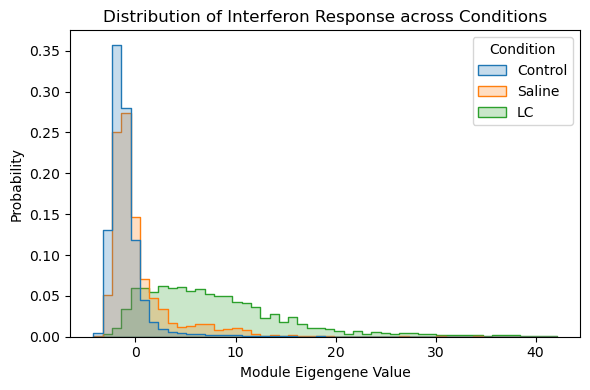

In [16]:
plot_module_distribution(meta_rn_df,
                         module_name="Interferon Response",
                         condition_key="Condition",
                         save_path="figures/Distribution_Interferon_Response_Hammond.svg",
                         figsize=(6, 4))

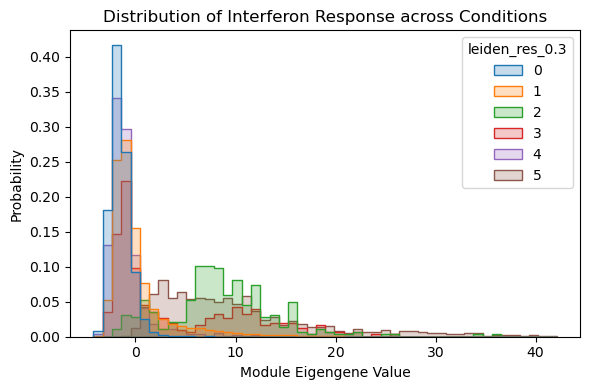

In [17]:
plot_module_distribution(meta_rn_df, module_name="Interferon Response", condition_key="leiden_res_0.3", figsize=(6, 4))

### Visualization: Hist plot of Genes

In [18]:
def plot_gene_distribution(adata, gene_name, condition_key="Condition", figsize=(8, 5), bins=50, use_raw=True, save_path=None):
    """
    Plot raw counts of a gene across different conditions.

    Parameters:
    - adata: AnnData object
    - gene_name: str, gene name to visualize
    - condition_key: str, key in `adata.obs` for grouping
    - figsize: tuple, figure size
    - bins: int, number of bins for histogram
    - use_raw: bool, whether to extract from adata.raw (if exists)
    """

    if use_raw:
        if adata.raw is None:
            raise ValueError("adata.raw is None. Set use_raw=False or check if raw counts are stored there.")
        source = adata.raw
    else:
        source = adata

    if gene_name not in source.var_names:
        raise ValueError(f"Gene '{gene_name}' not found in selected source (raw or main adata).")

    gene_expr = source[:, gene_name].X
    if hasattr(gene_expr, "toarray"):  # Handle sparse matrix
        gene_expr = gene_expr.toarray().flatten()
    else:
        gene_expr = gene_expr.flatten()
    
    df = pd.DataFrame({
        condition_key: adata.obs[condition_key].values,
        gene_name: gene_expr
    }).dropna()

    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=gene_name, hue=condition_key, element='step',
                 stat='probability', common_norm=False, bins=bins)
    plt.title(f"Raw Counts of {gene_name} Across Conditions")
    plt.xlabel("Raw Count")
    plt.ylabel("Probability")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

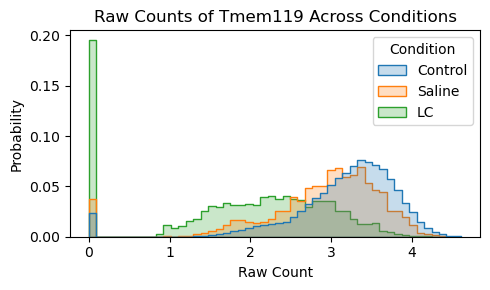

In [19]:
plot_gene_distribution(mg_intg,
                       gene_name="Tmem119",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_Tmem119_Hammond.svg"
                       )

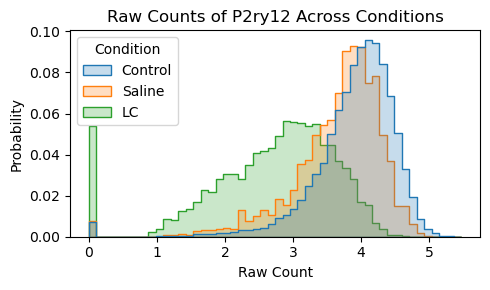

In [20]:
plot_gene_distribution(mg_intg,
                       gene_name="P2ry12",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_P2ry12_Hammond.svg"
                       )

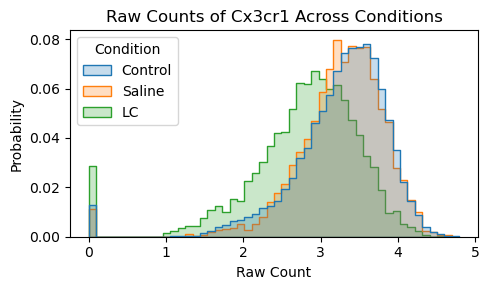

In [21]:
plot_gene_distribution(mg_intg,
                       gene_name="Cx3cr1",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_Cx3cr1_Hammond.svg"
                       )

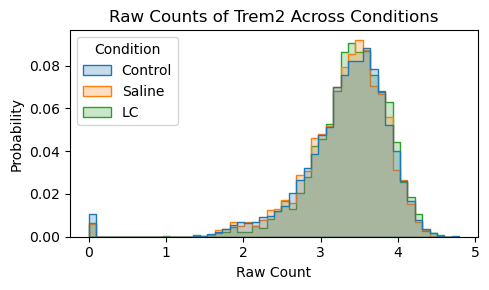

In [22]:
plot_gene_distribution(mg_intg,
                       gene_name="Trem2",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_Trem2_Hammond.svg"
                       )

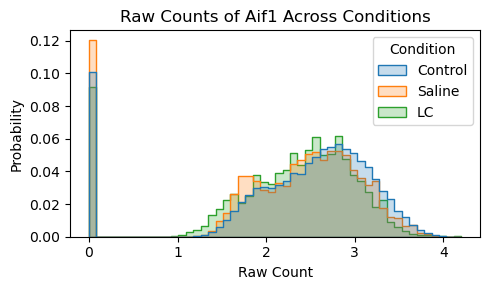

In [23]:
plot_gene_distribution(mg_intg,
                       gene_name="Aif1",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_Aif1_Hammond.svg"
                       )

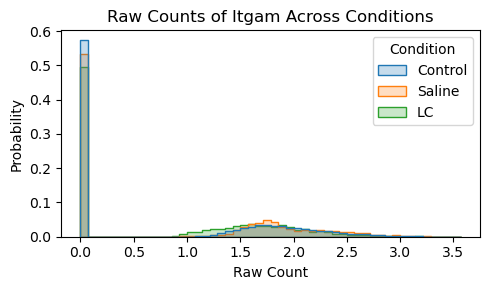

In [24]:
plot_gene_distribution(mg_intg,
                       gene_name="Itgam",
                       use_raw = True,
                       condition_key="Condition",
                       figsize=(5, 3),
                       save_path="figures/Distribution_Itgam_Hammond.svg"
                       )

### Visualization: UMAP

In [ ]:
# Ensure the indices match
assert all(MEs_rn_df.index == mg_intg.obs.index)

# Add the MEs_df to mg_ad.obs
mg_intg.obs = mg_intg.obs.join(MEs_rn_df)

# Verify the new columns
mg_intg.obs.head()

In [34]:
# # Add 'h' prefix to each column name in hMEs_df
# hMEs_df_renamed = hMEs_df.add_prefix('h')

# # Join the renamed dataframe to mg_ad.obs
# mg_ad.obs = mg_ad.obs.join(hMEs_df_renamed)

# # Verify the new columns are added
# mg_ad.obs.head()

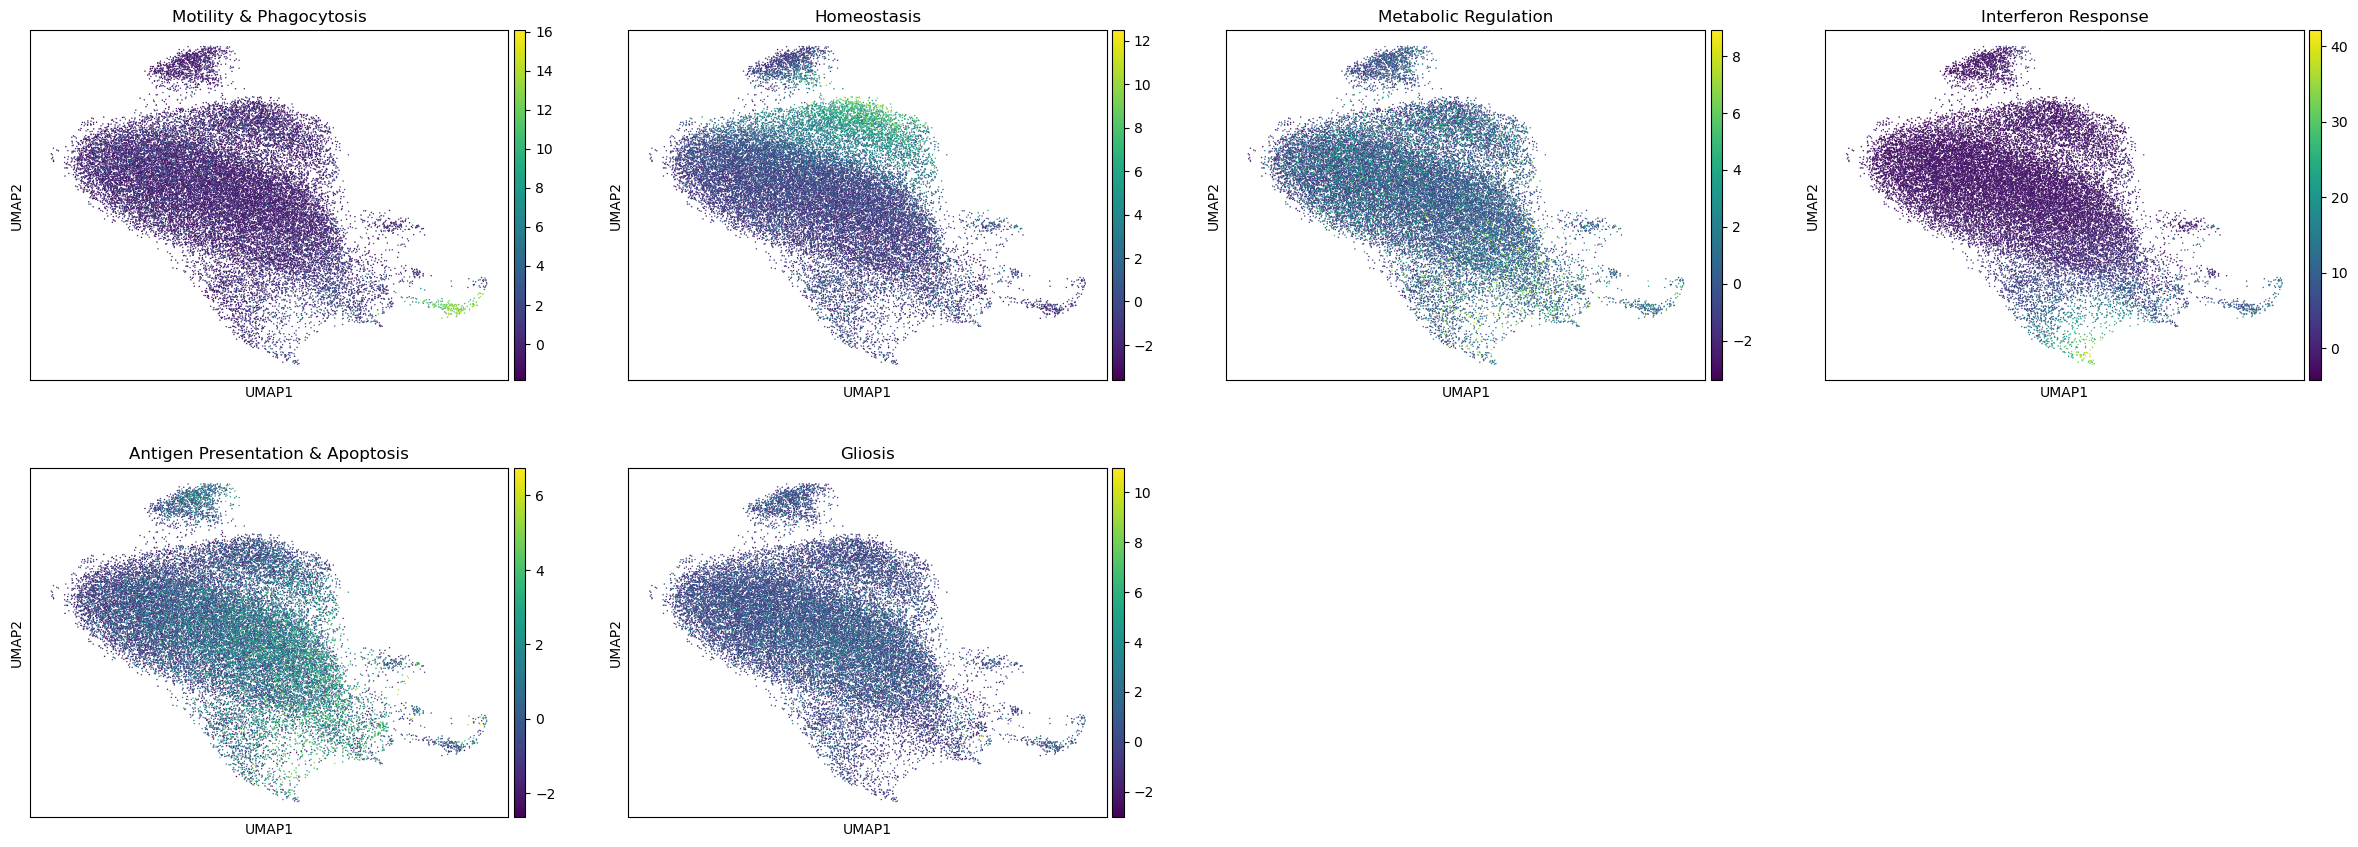

In [27]:
# Control modules
modules = MEs_rn_df.columns.tolist()
sc.pl.umap(mg_intg, color=modules)

### HEatmap: correlation of modules

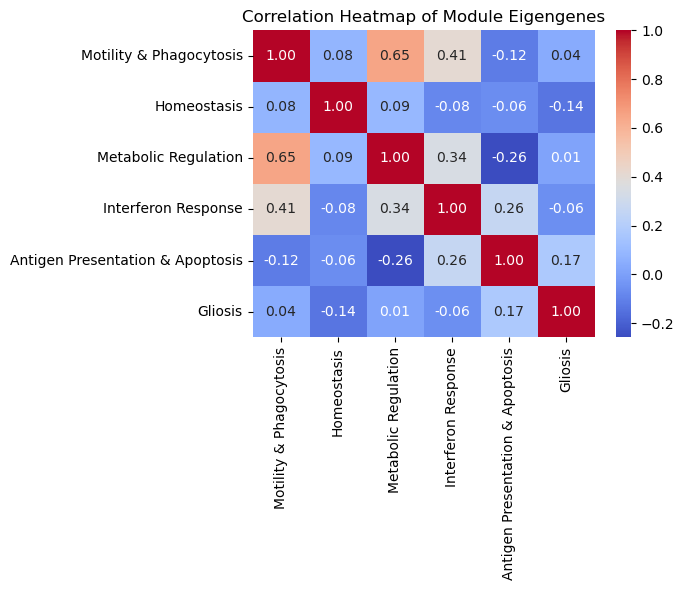

In [31]:
# Calculate the correlation matrix
corr_matrix = MEs_rn_df.corr()

# Plot the heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Module Eigengenes')
plt.tight_layout()
plt.savefig("figures/Heatmap_Module_Eigengenes_Hammond.svg")
plt.show()

In [33]:
# # Calculate the correlation matrix
# corr_matrix = hMEs_df.corr()

# # Plot the heatmap
# plt.figure(figsize=(7, 6))
# sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f')
# plt.title('Correlation Heatmap of Harmonized Module Eigengenes')
# plt.savefig('figures/Heatmap_correlation_Hammond_hMEs.svg')
# plt.show()

### Overlap with ABCA modules

In [47]:
# Selecting the brain region
select_region = "Microglia"

In [48]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
ABCA_MG_adata = sc.read_h5ad(expr_path)
ABCA_MG_adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [49]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
ABCA_modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
ABCA_modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [50]:
# Get genes for each module from ABCA_modules_df
abca_module_gene_sets = {}
for module in ABCA_modules_df['module'].unique():
    if module == "grey":
        continue
    abca_module_gene_sets[module] = set(
        ABCA_modules_df[ABCA_modules_df['module'] == module]['gene_name']
    )

# Example: print the number of genes in each module
for module, genes in abca_module_gene_sets.items():
    print(f"{module}: {len(genes)} genes")

MG-M1: 525 genes
MG-M2: 77 genes
MG-M3: 51 genes
MG-M4: 55 genes
MG-M5: 248 genes


In [51]:
# Map gene identifiers to gene names using ABCA_MG_adata.var["gene_symbol"]
gene_id_to_symbol = ABCA_MG_adata.var["gene_symbol"].to_dict()

# Create a new dictionary with gene symbols for each module
abca_module_gene_symbols = {}
for module, gene_ids in abca_module_gene_sets.items():
    symbols = {gene_id_to_symbol.get(gid, gid) for gid in gene_ids}
    abca_module_gene_symbols[module] = symbols

In [52]:
# Calculate overlap (intersection size) between ABCA and Hammond module gene sets
overlap_matrix = pd.DataFrame(
    index=abca_module_gene_symbols.keys(),
    columns=module_gene_sets.keys(),
    dtype=int
)

for abca_mod, abca_genes in abca_module_gene_symbols.items():
    for hammond_mod, hammond_genes in module_gene_sets.items():
        overlap_matrix.loc[abca_mod, hammond_mod] = len(abca_genes & hammond_genes)

# Display the overlap matrix
overlap_matrix

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
MG-M1,9.0,37.0,32.0,9.0,39.0,10.0,31.0,96.0,10.0,25.0
MG-M2,0.0,14.0,0.0,0.0,11.0,0.0,0.0,15.0,0.0,0.0
MG-M3,0.0,0.0,1.0,0.0,0.0,0.0,3.0,5.0,0.0,1.0
MG-M4,0.0,26.0,0.0,0.0,31.0,0.0,0.0,31.0,1.0,0.0
MG-M5,3.0,2.0,1.0,3.0,2.0,3.0,3.0,10.0,0.0,8.0


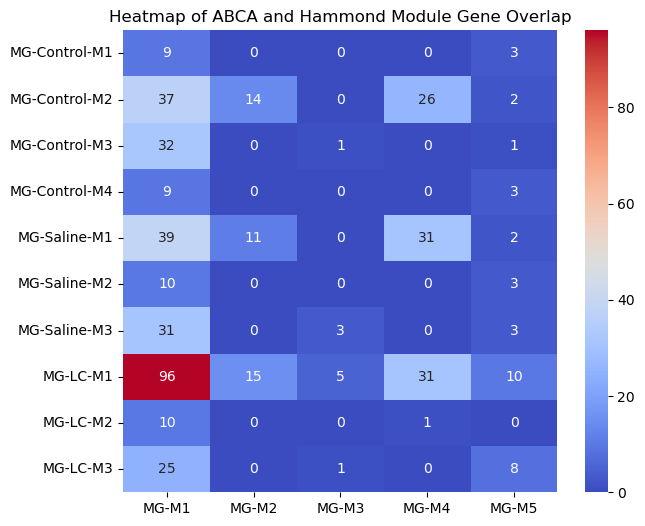

In [74]:
# Plot the heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(overlap_matrix.T, annot=True, cmap='coolwarm')
plt.title('Heatmap of ABCA and Hammond Module Gene Overlap')
plt.savefig('figures/Heatmap_ABCA_Hammond_module_overlap.svg')
plt.show()

### Module gene targets in MERFISH codebook

In [54]:
# Load codebook dataframe
codebook_path = Path("/data/MERFISH/codebook.csv")
codebook_df = pd.read_csv(codebook_path, index_col=0)
codebook_df.head()

,bit01,bit02,bit03,bit04,bit05,bit06,bit07,bit08,bit09,bit10,bit11,bit12,bit13,bit14,bit15,bit16
Adgre1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0
Adrb2,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1
Angpt1,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0
Angpt2,0,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0
Axl,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,0


In [55]:
# Count how many genes from each module exist in the codebook dataframe
genes_in_codebook = {}

for mod, genes in module_gene_sets.items():
    genes_in_codebook[mod] = len(set(codebook_df.index).intersection(genes))

# Display as a pandas Series for readability
genes_in_codebook_series = pd.Series(genes_in_codebook)
print(genes_in_codebook_series)

MG-Control-M1     7
MG-Control-M2    31
MG-Control-M3    20
MG-Control-M4    14
MG-Saline-M1     34
MG-Saline-M2      4
MG-Saline-M3     13
MG-LC-M1         41
MG-LC-M2          7
MG-LC-M3         20
dtype: int64


### GO

In [56]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_sets.items():
    if module == "grey":
        continue
    
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=list(genes),
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

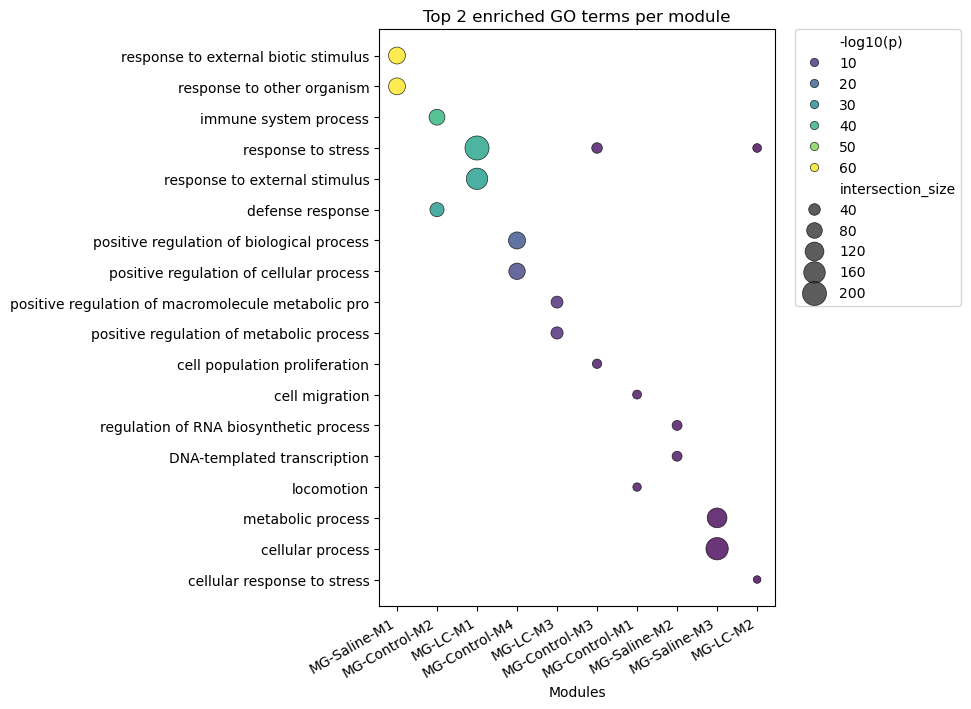

In [68]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("figures/dotplot_GO_Hammond_modules.svg")
plt.show()

### ME activation across conditions

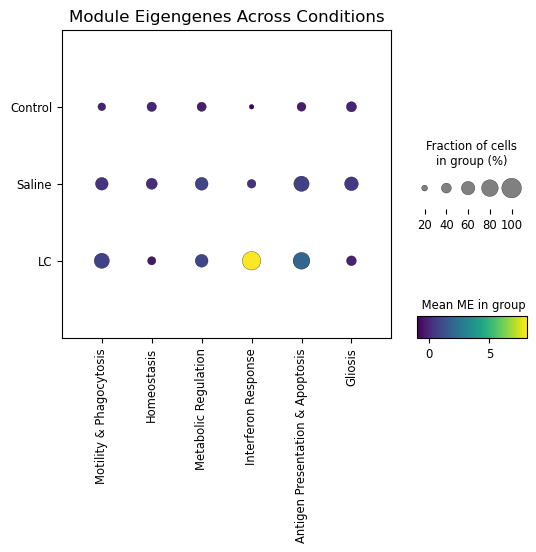

In [12]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(MEs_rn_df)
adata_vis.obs["Condition"] = mg_intg.obs["Condition"]  # Add cell type labels

# Dotplot
sc.pl.dotplot(
    adata_vis,
    var_names=MEs_rn_df.columns,
    groupby="Condition",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(6, 4),  # Adjust size as needed
    title="Module Eigengenes Across Conditions",
    colorbar_title=" Mean ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    save="Hammond_modules.svg",
    use_raw=False,
)

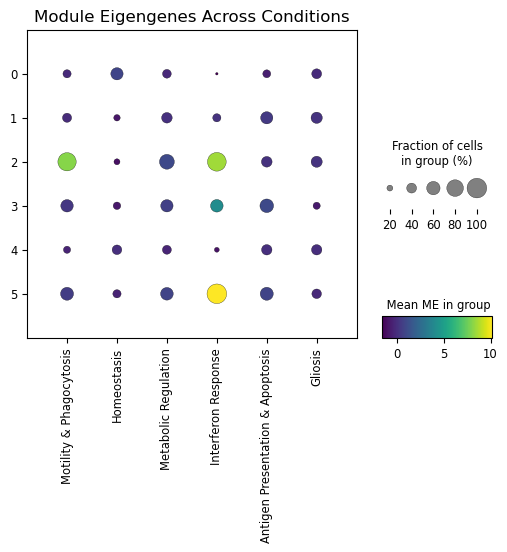

In [13]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(MEs_rn_df)
adata_vis.obs["Clusters"] = mg_intg.obs["leiden_res_0.3"]  # Add cell type labels

# Dotplot
sc.pl.dotplot(
    adata_vis,
    var_names=MEs_rn_df.columns,
    groupby="Clusters",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(6, 4),  # Adjust size as needed
    title="Module Eigengenes Across Conditions",
    colorbar_title=" Mean ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    save="Hammond_modules_across_clusters.svg",
    use_raw=False,
)

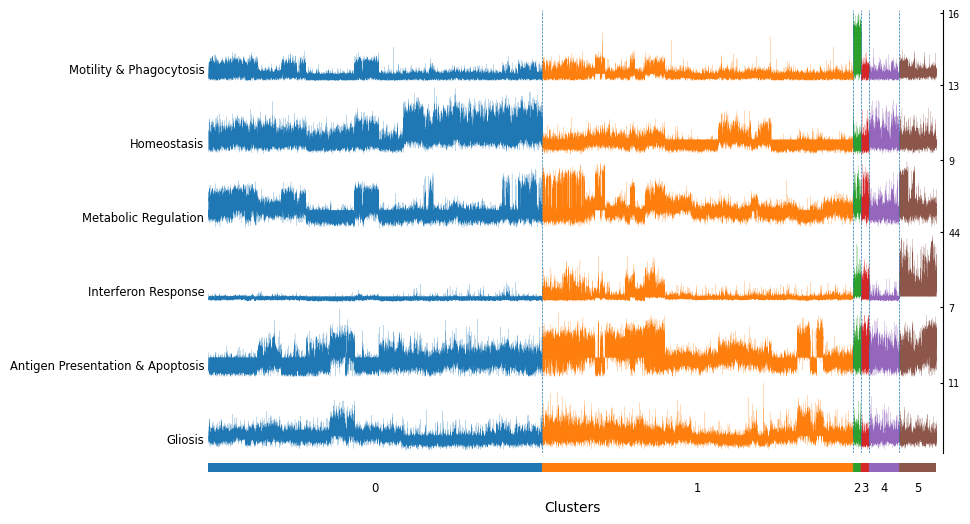

In [28]:
# Add all module eigengenes to AnnData and class labels
adata_tracks = sc.AnnData(MEs_rn_df)
adata_tracks.obs["Clusters"] = mg_intg.obs["leiden_res_0.3"]

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=MEs_rn_df.columns,
    groupby="Clusters",
    figsize=(10, 6),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
    # save = "_Hammond_modules.png"
)

### Literature signatures scoring

In [75]:
microglia_gene_signatures = {
    "homeostatic": [
        "P2ry12", "Tmem119", "Cx3cr1", "Siglech", "Hexb", "Fcrls", 
        "Gpr34", "Olfml3", "Sall1", "Csf1r", "Cst3"
    ],
    "dam_stage1_upregulated": [
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd"
    ],
    "dam_stage2_upregulated": [
        "Trem2", "Axl", "Itgax", "Cd9", "Cd63", "Csf1", "Ccl6",
        "Igf1", "Lyz2", "Cybb", "Lpl", "Cst7", "Ctsl", "Ctsz", 
        "Lilrb4a", "Spp1", "Timp2"
    ],
    "dam_all_upregulated": [ # A combined list of all upregulated DAM genes
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd", "Fth1", "Trem2", "Axl", "Itgax", 
        "Cd9", "Cd63", "Csf1", "Ccl6", "Igf1", "Lyz2", "Cybb", "Lpl", 
        "Cst7", "Ctsl", "Ctsz", "Lilrb4a", "Spp1", "Timp2"
    ],
    "ifn_response": [ # Type I Interferon Response Microglia
        "Ifit1", "Ifit3", "Ifitm3", "Isg15", "Oasl2", "Irf7"
    ],
    "mhc_ii": [ # MHC-II Microglia
        "H2.Aa", "H2.Ab1", "H2.Eb1", "Cd74", "Hif1a"
    ],
    "arm": [ # Activated Response Microglia (largely overlaps with DAM)
        "Itgax", "Cst7", "Cd74", "H2.Aa", "H2.Ab1", "Apoe", "Lpl"
    ],
    "proliferating": [
        "Pcna"
    ],
    "aging_associated": [ # General aging markers, includes ARM/DAM-like and IRM genes
        "Ccl3", "Ccl4", "Il1b", "Itgax", "Spp1", "Apoe", "Ifitm3", "Irf7",
        "Lpl", "Lgals3", "Cst7", "H2.Aa", "H2.Ab1"
    ],
    "lps_induced_upregulated": [ # Acute inflammation model
        "Rplp0", "Rps2", "Cd52", "Cd63", "Ctsl", "Manf", "Pdia4", "Calm1", 
        "Fth1", "C5ar1", "Hacd2", "Gnl3"
    ],
    "nerve_injury_associated": [ # Markers associated with chronic nerve injury contexts
        "Apoe", "Spp1", "Lpl", "Atf3", "Vim", "Itgax", "Lgals3"
    ],
    "pan_microglial_markers": [ # General markers for identifying microglia
        "Itgam", "Aif1", "Cx3cr1", "Csf1r", "Ptprc"
    ]
}

In [76]:
# Check which genes in microglia_gene_signatures are missing from adata.var_names
missing_genes = {}
for signature, genes in microglia_gene_signatures.items():
    missing = [g for g in genes if g not in mg_ad.var_names]
    if missing:
        missing_genes[signature] = missing

for signature, genes in missing_genes.items():
    print(f"Signature '{signature}' missing genes in adata: {genes}")

In [77]:
def search_genes(keyword, adata):
    """
    Search for genes in adata.var_names containing the given keyword (case-insensitive).
    Returns a list of matching gene names.
    """
    keyword = keyword.lower()
    matches = [gene for gene in adata.var_names if keyword in gene.lower()]
    return matches

In [78]:
# Example usage:
genes_found = search_genes("Ch2", mg_ad)
print(genes_found)

['Bach2', 'Bach2os', 'Gpatch2', 'Gpatch2l', 'March2', 'Mtch2', 'Notch2', 'Qrich2']


In [79]:
# Score each signature using scanpy's score_genes function
for signature_name, gene_list in microglia_gene_signatures.items():
    # Only keep genes present in adata.var_names
    genes_in_data = [g for g in gene_list if g in mg_intg.var_names]
    if len(genes_in_data) == 0:
        print(f"Signature '{signature_name}': no genes found in adata.var_names, skipping.")
        continue
    sc.tl.score_genes(mg_intg, gene_list=genes_in_data, score_name=f"{signature_name}_score", use_raw=False)
    print(f"Scored signature: {signature_name} ({len(genes_in_data)} genes)")

# The scores are now in adata.obs with columns like 'homeostatic_score', etc.
mg_intg.obs[[f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in mg_intg.obs.columns]].head()

Scored signature: homeostatic (11 genes)
Scored signature: dam_stage1_upregulated (5 genes)
Scored signature: dam_stage2_upregulated (17 genes)
Scored signature: dam_all_upregulated (23 genes)
Scored signature: ifn_response (6 genes)
Scored signature: mhc_ii (5 genes)
Scored signature: arm (7 genes)
Scored signature: proliferating (1 genes)
Scored signature: aging_associated (13 genes)
Scored signature: lps_induced_upregulated (12 genes)
Scored signature: nerve_injury_associated (7 genes)
Scored signature: pan_microglial_markers (5 genes)


,homeostatic_score,dam_stage1_upregulated_score,dam_stage2_upregulated_score,dam_all_upregulated_score,ifn_response_score,mhc_ii_score,arm_score,proliferating_score,aging_associated_score,lps_induced_upregulated_score,nerve_injury_associated_score,pan_microglial_markers_score
TTAGGACAGAGGGCTT-1-0,-3.451750,-1.829810,-1.095535,-1.198848,-0.296833,-0.363309,-0.140481,-0.895337,-0.128589,-0.999175,-0.001103,-2.596785
GGCGACTTCCAAATGC-1-0,0.211404,-0.502904,-0.097857,-0.209915,-0.390810,-0.028550,-0.270810,-0.441407,-0.297437,0.101397,-0.169726,0.729755
TCATTACTCGTGGACC-1-0,-0.139763,0.131524,-0.056910,0.056689,-0.301292,0.203078,-0.327390,1.368363,-0.123252,0.239578,-0.243235,0.509966
GCAAACTTCGGCGGTT-1-0,-0.662981,0.071763,0.445495,0.432190,2.849768,7.113167,3.879957,-0.592384,1.994696,0.353629,1.798777,-0.073468
GGAATAATCACAGGCC-1-0,0.205887,-0.385924,-0.266354,-0.349938,-0.355080,0.212438,-0.367450,-0.373722,-0.349870,-0.019317,-0.229289,-0.150014


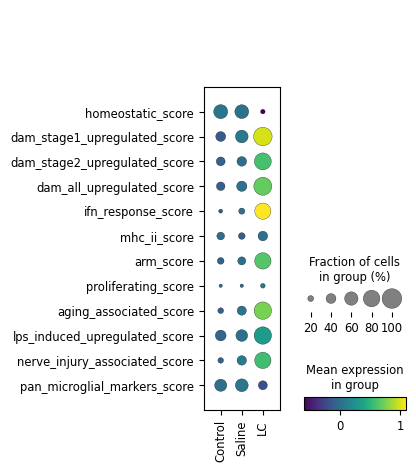

In [84]:
# Visualize gene set scores as a dotplot across clusters
score_cols = [f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in mg_intg.obs.columns]
cluster_col = "Condition"

# Visualize gene set scores as a dotplot across clusters using scanpy's dotplot
sc.pl.dotplot(
    mg_intg,
    var_names=score_cols,  # gene set score columns in .obs
    groupby=cluster_col,
    standard_scale=None,   # do not z-score, show raw scores
    use_raw=False,
    dot_max=None,
    color_map="viridis",
    swap_axes=True,        # signatures on y-axis, clusters on x-axis
    show=True
)